Isabella Esquivel
Feburary 19, 2026
University of Miami
College of Engineering
Coral Gables, FL 33146

# 1. Introduction

####1.1 Background

According to Mayo Clinic, heart failure occurs when the heart muscle does not pump blood as it should, causing blood to back up. This may lead to fluid building in the lungs, causing shortness of breath. The Heart Failure Society of America reported that heart failure was a contributing cause in 425,147 deaths in the United States in 2022, making up 45% of cardiovascular deaths.

Medical records of patients who have undergone heart failure could be used to analyze and identify patterns in patient survival. These clinical factors include ejection fraction, serum creatinine, and serum sodium as well as other demographic factors, such as age and gender. Understanding how these clinical indicators relate is essential to quantifying the risk of death following heart failure and to improve disease management.

####1.2 Prior Studies

Chicco and Jurman(2020) previously demonstrated that the strongest predictors of mortality among heart failure patients were serum creatinine and ejection fraction by using machine learning classification techniques. Additionally, in 2017, Ahmad and colleagues conducted a survival analysis, and found that age, renal dysfunction(having serum creatinine greater than
its normal level 1.5), high blood pressure, high levels of anaemia, and lower values of ejection fraction as the most significant risk factors for death following heart failure.

####1.3 Study Objective

However, the previous research on this data set focused mostly on predicting survival rather than examining linear relationships amongst the risk factors. Therefore, the present study aims to apply classical linear regression techniques to investigate how demographic and clinical variables relate to key risk indicators, specifically ejection fraction and serum creatinine, in patients with heart failure.

# 2. Data and Methods

 ### 2.1 Dataset Description

The dataset used consists of 299 patients with heart failure. 13 clinical and demographic variables were collected from each patient, including age, sex, anaemia status, diabetes status, high blood pressure, smoking status, serum creatinine, serum sodium, creatinine phosphoinase(CPK), platelet count, follow-up time, ejection fraction, and death event (see table 1 for descriptions).

In [ ]:
knitr::kable(variable_table, caption = "Table 1. Description of Clinical Variables Included in the Heart Failure Dataset")




Table: Table 1. Description of Clinical Variables Included in the Heart Failure Dataset

|Variable                 |Description                                           |
|:------------------------|:-----------------------------------------------------|
|age                      |Age of the patient (years)                            |
|anaemia                  |Decrease of red blood cells or hemoglobin (boolean)   |
|creatinine_phosphokinase |Level of CPK enzyme in blood (mcg/L)                  |
|diabetes                 |Presence of diabetes (boolean)                        |
|ejection_fraction        |Percentage of blood leaving heart at each contraction |
|high_blood_pressure      |Presence of hypertension (boolean)                    |
|platelets                |Platelets in blood (kiloplatelets/mL)                 |
|sex                      |Sex (binary: 0 = female, 1 = male)                    |
|serum_creatinine         |Serum creatinine level (mg/dL)                      

The primary response variables for this analysis are ejection fraction (EF), and serum creatinine.

In [ ]:
HeartFailure <- read.csv("HeartFailure.csv")

In [ ]:
head(HeartFailure)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,75,0,582,0,20,1,265000,1.9,130,1,0,4,1
2,55,0,7861,0,38,0,263358,1.1,136,1,0,6,1
3,65,0,146,0,20,0,162000,1.3,129,1,1,7,1
4,50,1,111,0,20,0,210000,1.9,137,1,0,7,1
5,65,1,160,1,20,0,327000,2.7,116,0,0,8,1
6,90,1,47,0,40,1,204000,2.1,132,1,1,8,1


### 2.2 Simple Linear Regression Models

To explore the relationships among the clinical variables, we begin by fitting simple linear regression models using the `lm()` function in R. The general syntax is `lm(y ~ x, data)`, where `y` represents the response variable, `x` is the predictor variable, and `data` is the data frame containing the variables of interest.

The general simple linear regression model is defined as:

$$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i \tag{1}
$$

The variables death_event and time were excluded from the regression analyses because they represent survival outcomes rather than clinical factors.

###### 2.2.1 Model I: Ejection Fraction as Response

Since ejection fraction has been identified as a key indicator of survival after heart failure, ejection fraction was modeled as a continuous response variable. The simple linear regression model is given by:

$$
EF_i = \beta_0 + \beta_1 X_i + \varepsilon_i
\tag{1}
$$

where $EF_i$ represents the ejection fraction of patient $i$, $X_i$ represents a clinical predictor, and $\varepsilon_i$ is the random error term.

The models were estimated in R using the `lm()` function. For example, the association between ejection fraction and serum sodium was estimated using:

`lm(ejection_fraction ~ serum_sodium, data = HeartFailure)`

Similar models were fitted for each predictor variable individually, including age, serum sodium, serum creatinine, creatinine phosphokinase, platelet count, sex, anaemia, diabetes, smoking, and high blood pressure.

The following code is utilized to attach the dataset for plotting and modeling purposes.

In [ ]:
attach(HeartFailure)

Age: lm_age1

In [ ]:
lm_age1 <- lm(ejection_fraction ~ age, data = HeartFailure)

The scatterplot of age versus ejection fraction shows a very slight positive linear trend, as indicated by the fitted regression line. However, the data points are widely dispersed around the line, suggesting variability in ejection fraction across ages.

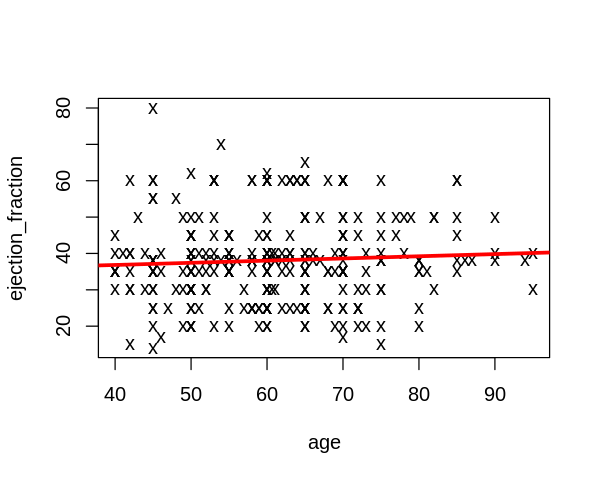

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(age, ejection_fraction, pch="x")
abline(lm_age1, lwd=3, col="red")

The estimated regression equation indicates that ejection fraction increases by approximately 0.06 percentage points for each additional year of age with intercept (34.45). The small size of the slope implies that age has only a minimal effect.

$$
\widehat{EF} = 34.446 + 0.0598(\text{age})
$$

In [ ]:
names(lm_age1)
coefficients(lm_age1)
lm_age1

[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "xlevels"       "call"          "terms"         "model"

(Intercept)         age 
34.44602666  0.05979537


Call:
lm(formula = ejection_fraction ~ age, data = HeartFailure)

Coefficients:
(Intercept)          age  
    34.4460       0.0598  


Serum Sodium: lm_sodium1

In [ ]:
lm_sodium1 <- lm(ejection_fraction ~ serum_sodium, data = HeartFailure)

The scatterplot of serum sodium versus ejection fraction shows a positive linear trend, as indicated by the fitted regression line. However, the data points are widely dispersed around the line, suggesting variability in ejection fraction across serum sodium levels.

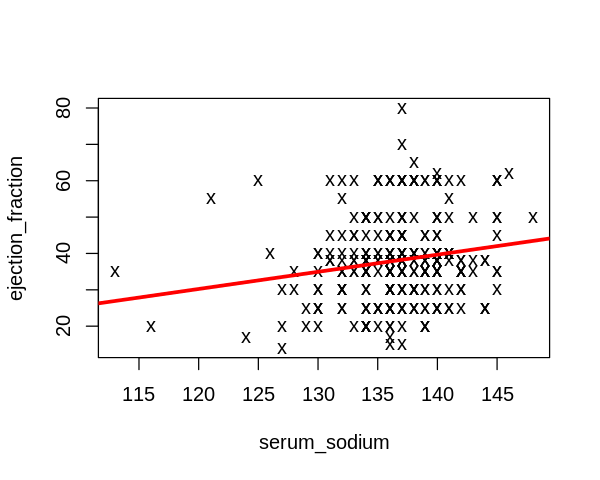

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(serum_sodium, ejection_fraction, pch="x")
abline(lm_sodium1, lwd=3, col="red")

The estimated regression equation indicates that ejection fraction decreases by approximately 0.47 percentage points as serum sodium level increases, with intercept (-26.375). The small size of the slope implies that age has only a minimal effect.

$$
\widehat{EF} = -26.375 + 0.472(\text{serum sodium})
$$

In [ ]:
lm_sodium1


Call:
lm(formula = ejection_fraction ~ serum_sodium, data = HeartFailure)

Coefficients:
 (Intercept)  serum_sodium  
    -26.3753        0.4718  


Serum Creatinine: lm_creatinine1

In [ ]:
lm_creatinine1 <- lm(ejection_fraction ~ serum_creatinine, data = HeartFailure)

The scatterplot of serum creatinine versus ejection fraction shows a very little trend, as indicated by the fitted regression line. However, the data points are concentrated on one side of the graph.

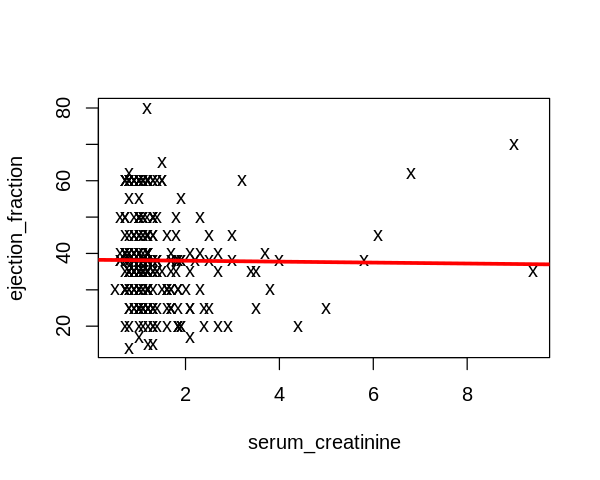

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(serum_creatinine, ejection_fraction, pch = "x")
abline(lm_creatinine1, lwd=3,col="red")

The estimated regression equation indicates that ejection fraction decreases by approximately 0.1293 percentage points as serum sodium level increases, with intercept (38.26). The small size of the slope implies that serum creatinine has only a minimal effect.

$$
\widehat{EF} = 38.2638 -0.1293(\text{creatinine})
$$

In [ ]:
coefficients(lm_creatinine1)

(Intercept) serum_creatinine 
      38.2638418       -0.1293008

Creatinine Phosphokinase: lm_phosphokinase1

In [ ]:
lm_phosphokinase1 <- lm(ejection_fraction ~ creatinine_phosphokinase, data = HeartFailure)

The scatterplot of creatinine phosphokinase versus ejection fraction shows very little trend, as indicated by the fitted regression line. However, the data points are concentrated on one side of the graph.

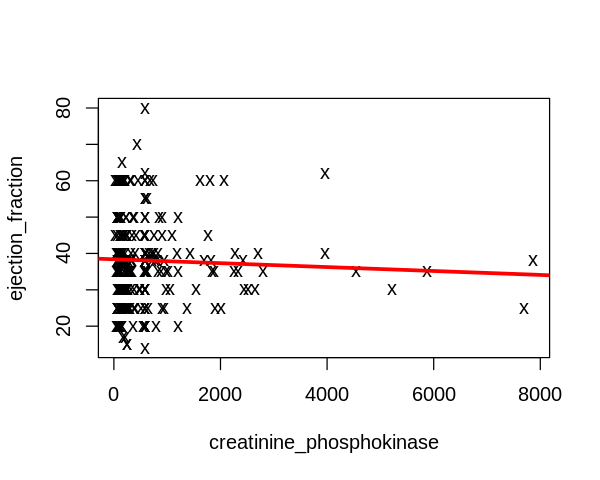

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(creatinine_phosphokinase, ejection_fraction, pch = "x")
abline(lm_phosphokinase1, lwd=3,col="red")

The estimated regression equation indicates that ejection fraction decreases by approximately 0.0005376 percentage points as phosphokinase level increases, with intercept (38.39). The small size of the slope implies that creatinine phosphokinase has only a minimal effect.

$$
\widehat{EF} = 38.396 -0.0005376(\text{phosphokinase})
$$

In [ ]:
coefficients(lm_phosphokinase1)

(Intercept) creatinine_phosphokinase 
           38.3964375654            -0.0005376492

Platelet Count: lm_platelet1

In [ ]:
lm_platelet1 <- lm(ejection_fraction ~ platelets, data = HeartFailure)

The scatterplot of platelet versus ejection fraction shows a slight positive trend, as indicated by the fitted regression line. However, the data points are concentrated on one area of the graph.

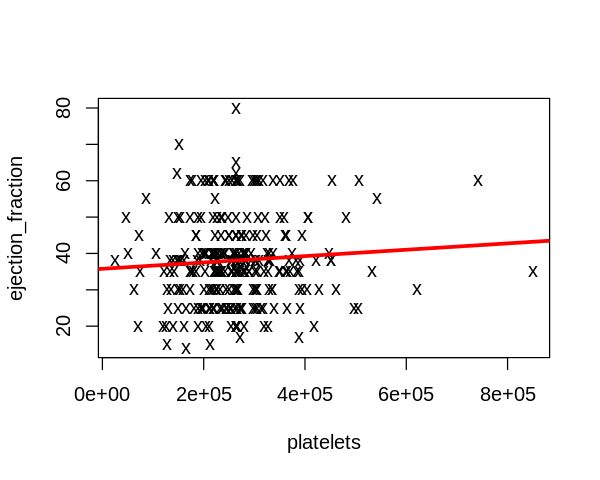

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(platelets, ejection_fraction, pch = "x")
abline(lm_platelet1, lwd=3, col="red")

The estimated regression equation indicates that ejection fraction decreases by approximately 8.734e-06  percentage points as platelet level increases, with intercept (35.78). The small size of the slope implies that platelet levels have only a minimal effect.

$$
\widehat{EF}_i = 35.7835 + 8.734 \times 10^{-6} (\text{platelets})
$$

In [ ]:
coefficients(lm_platelet1)

(Intercept)    platelets 
3.578348e+01 8.733863e-06

Sex: lm_sex1

In [ ]:
lm_sex1 <- lm(ejection_fraction ~ sex, data = HeartFailure)

The scatterplot of sex versus ejection fraction shows a slight trend due to gender, as indicated by the fitted regression line.

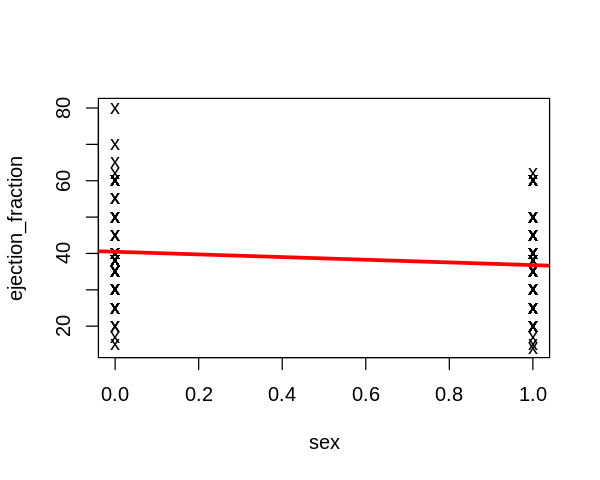

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(sex, ejection_fraction, pch ="x")
abline(lm_sex1, lwd=3, col="red")

The intercept (40.467) represents the average ejection fraction for females, and the coefficient (−3.673) indicates that males have an average ejection fraction 3.673 percentage points lower than females.

$$
\widehat{EF} = 40.467 -3.673(\text{phosphokinase})
$$

In [ ]:
coefficients(lm_sex1)

(Intercept)         sex 
  40.466667   -3.672852

Anaemia: lm_anaemia1

In [ ]:
lm_anaemia1 <- lm(ejection_fraction ~ anaemia, data = HeartFailure)

The scatterplot of anaemia versus ejection fraction shows a very little trend due to anaemia, as indicated by the fitted regression line.

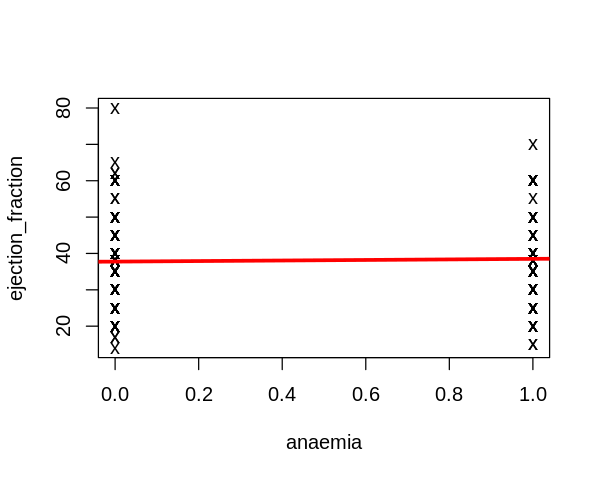

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(anaemia, ejection_fraction, pch = "x")
abline(lm_anaemia1, lwd=3, col="red")

$$
\widehat{EF} = 37.7588 + 0.7528(\text{anaemia})
$$

The estimated regression equation indicates that ejection fraction decreases by approximately 0.7528 percentage points due to anaemia with intercept (37.75).

In [ ]:
coefficients(lm_anaemia1)

(Intercept)     anaemia 
 37.7588235   0.7528044

Diabetes: lm_diabetes1

In [ ]:
lm_diabetes1 <- lm(ejection_fraction ~ diabetes, data = HeartFailure)

The scatterplot of diabetes versus ejection fraction shows little to no trend due to diabetes, as indicated by the fitted regression line.

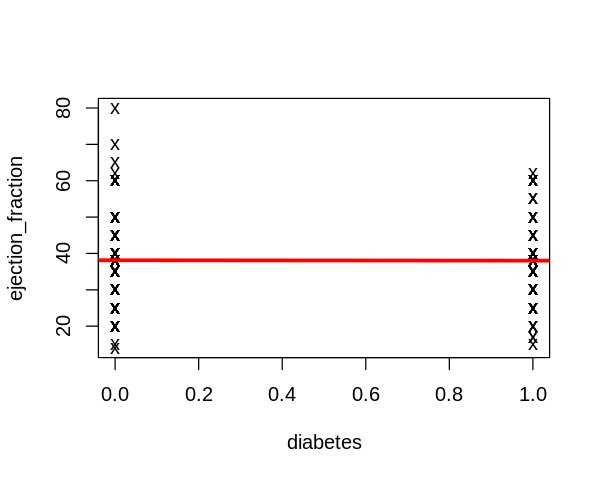

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(diabetes, ejection_fraction, pch = "x")
abline(lm_diabetes1, lwd=3, col="red")

$$
\widehat{EF} = 38.132 -0.116(\text{diabetes})
$$

The estimated regression equation indicates that ejection fraction decreases by approximately 0.116 percentage points with intercept (38.1322). However, the small size slope indicates minimal effect.

In [ ]:
coefficients(lm_diabetes1)

(Intercept)    diabetes 
 38.1321839  -0.1161839

Smoking: lm_smoking1

In [ ]:
lm_smoking1<- lm(ejection_fraction ~ smoking, data = HeartFailure)

The scatterplot of smoking versus ejection fraction shows little to no trend due to smoking, as indicated by the fitted regression line.

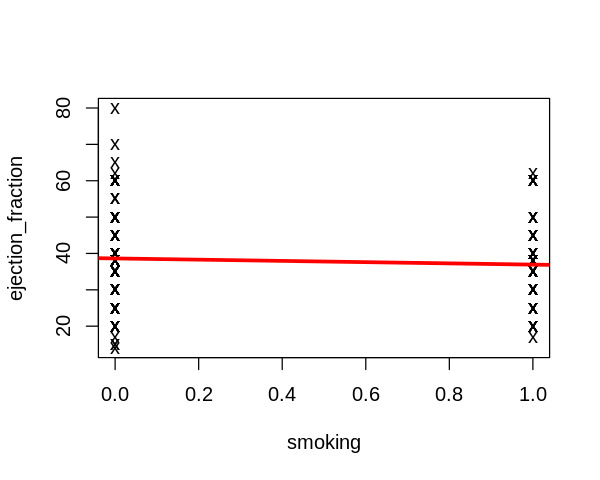

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(smoking, ejection_fraction, pch = "x")
abline(lm_smoking1, lwd=3, col="red")

$$
\widehat{EF} = 38.631 -1.703(\text{smoking})
$$

The estimated regression equation indicates that ejection fraction decreases by approximately -1.703 percentage points with intercept (38.631). However, the small size slope indicates minimal effect.

In [ ]:
coefficients(lm_smoking1)

(Intercept)     smoking 
  38.630542   -1.703459

High Blood Pressure: lm_pressure1

In [ ]:
lm_pressure1<- lm(ejection_fraction ~ high_blood_pressure, data = HeartFailure)

The scatterplot of high blood pressure versus ejection fraction shows little to no trend due to high blood pressure, as indicated by the fitted regression line.

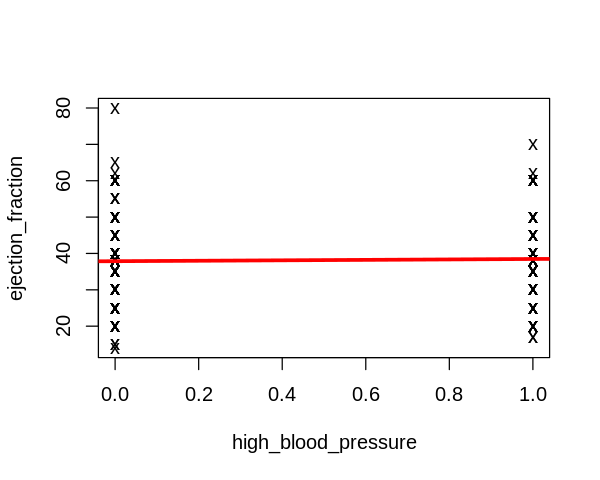

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(high_blood_pressure, ejection_fraction, pch = "x")
abline(lm_pressure1, lwd=3, col="red")

$$
\widehat{EF} = 37.8711 + 0.6051(\text{high_blood_pressure})
$$

The estimated regression equation indicates that ejection fraction increases by approximately 0.6051 percentage points with intercept (37.8711). However, the small size slope indicates minimal effect.

In [ ]:
coefficients(lm_pressure1)

(Intercept) high_blood_pressure 
         37.8711340           0.6050565

###### 2.2.2 Model II: Serum Creatinine as Response

Since serum creatinine has been identified as a key indicator of survival after heart failure, serum creatinine was modeled as a continuous response variable:

$$
\text{Creatinine}_i = \beta_0 + \beta_1 X_i + \varepsilon_i
\tag{3}
$$

Age: lm_age2

In [ ]:
lm_age2 <- lm(serum_creatinine ~ age, data = HeartFailure)

The scatterplot of age versus serum creatinine shows a slight positive trend due to age, as indicated by the fitted regression line. Additionally, there is some concentration in the data points; however, this could be due to dataset rather than true relationships.

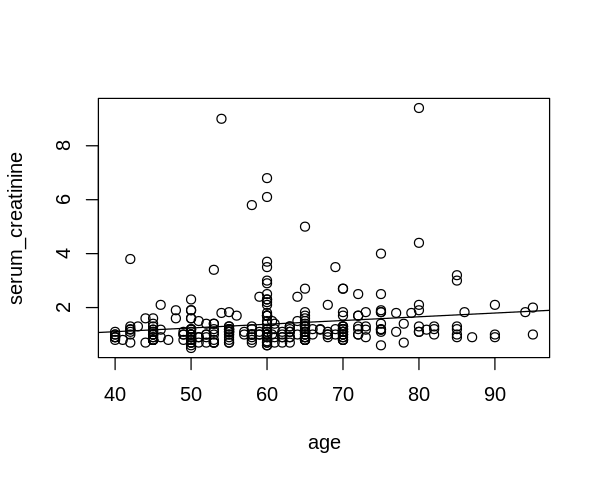

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(age, serum_creatinine)
abline(lm_age2)

$$
\widehat{Creatinine} = 0.55165 + 0.01384(\text{age})
$$

The estimated regression equation indicates that serum creatinine increases by approximately 0.01384 percentage points with intercept (0.55165). However, the small size slope indicates minimal effect.

In [ ]:
coefficients(lm_age2)

(Intercept)         age 
 0.55164939  0.01384475

Serum Sodium: lm_sodium2

In [ ]:
lm_sodium2 <- lm(serum_creatinine ~ serum_sodium, data = HeartFailure)

The scatterplot of serum sodium versus serum creatinine shows a negative trend due to serum sodium, as indicated by the fitted regression line. Additionally, there is some concentration in the data points around the 135-145 area of the graph.

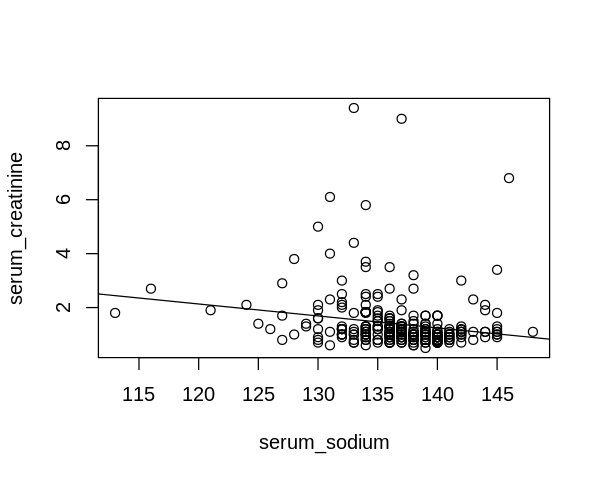

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(serum_sodium, serum_creatinine)
abline(lm_sodium2)

$$
\widehat{Creatinine} = 7.45 -0.04433(\text{serum_sodium})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately 0.04433 percentage points with intercept (7.45). However, the small size slope indicates minimal effect.

In [ ]:
coefficients(lm_sodium2)

(Intercept) serum_sodium 
  7.45097298  -0.04433358

Ejection Fraction: lm_ejection2

In [ ]:
lm_ejection2 <- lm(serum_creatinine ~ejection_fraction, data = HeartFailure)

The scatterplot of ejection fraction versus serum creatinine shows very little to no trend due to ejection fraction, as indicated by the fitted regression line. Additionally, there is some concentration in the data points in the bottom half of the graph.

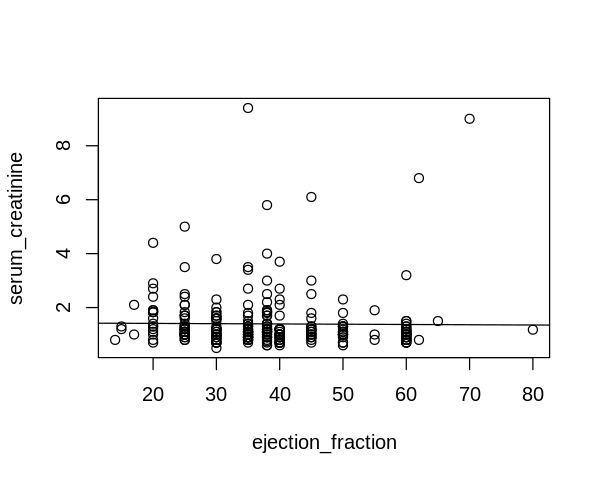

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(ejection_fraction, serum_creatinine)
abline(lm_ejection2)

$$
\widehat{Creatinine} = 1.43105 -0.000988(\text{ejection_fraction})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately 0.000988 percentage points with intercept (1.43). However, the small size slope indicates minimal effect.

In [ ]:
coefficients(lm_ejection2)

(Intercept) ejection_fraction 
     1.4315052467     -0.0009879748

Creatinine Phosphokinase: lm_phosphokinase2

In [ ]:
lm_phosphokinase2 <- lm(serum_creatinine ~ creatinine_phosphokinase, data = HeartFailure)

The scatterplot of creatinine phosphokinase versus serum creatinine shows very little to no trend due to creatinine phosphokinase, as indicated by the fitted regression line. However, there is much concentration in the data points in the bottom left half of the graph.

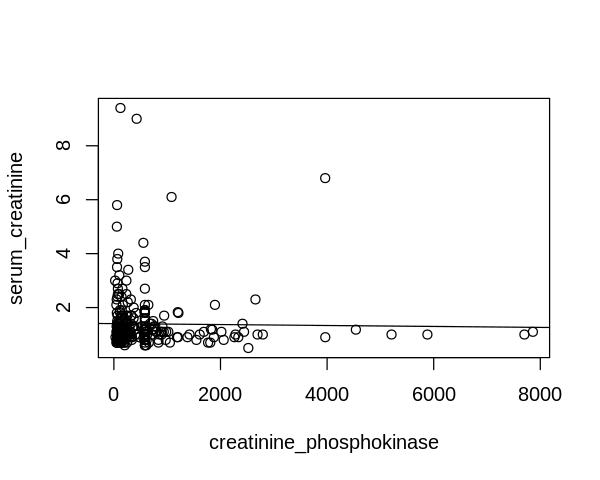

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(creatinine_phosphokinase, serum_creatinine)
abline(lm_phosphokinase2)

$$
\widehat{Creatinine}_i = 1.4041 - 1.749 \times 10^{-5} (\text{creatinine phosphokinase})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately -1.749e-05 percentage points with intercept (1.404e+00). However, the small size slope indicates minimal effect.

In [ ]:
coefficients(lm_phosphokinase2)

(Intercept) creatinine_phosphokinase 
            1.404059e+00            -1.749454e-05

Platelet Count: lm_platelet2

In [ ]:
lm_platelet2 <- lm(serum_creatinine~ platelets, data = HeartFailure)

The scatterplot of platelet versus serum creatinine shows very little to no trend due to platelet level, as indicated by the fitted regression line. However, there is much concentration in the data points around the bottom left half of the graph.

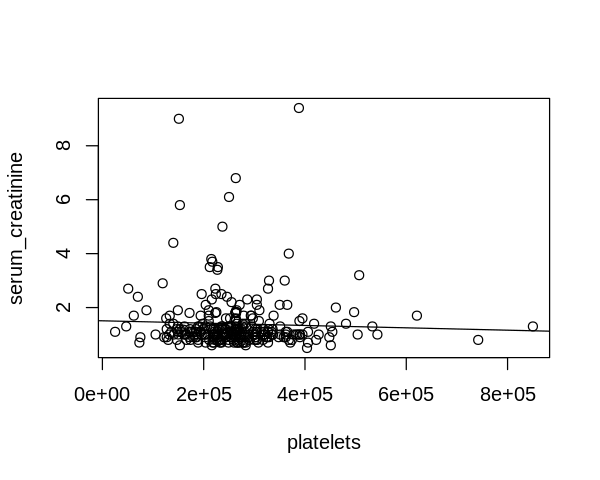

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(platelets, serum_creatinine)
abline(lm_platelet2)

$$
\widehat{Creatinine}_i = 1.509  - 4.358 \times 10^{-7} (\text{platelets})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately -4.358e-07 percentage points with intercept (1.509).

In [ ]:
coefficients(lm_platelet2)

(Intercept)     platelets 
 1.508642e+00 -4.357667e-07

Sex: lm_sex2

In [ ]:
lm_sex2 <- lm(serum_creatinine ~ sex, data = HeartFailure)

The scatterplot of sex versus serum creatinine shows very little to no trend due to sex, as indicated by the fitted regression line.

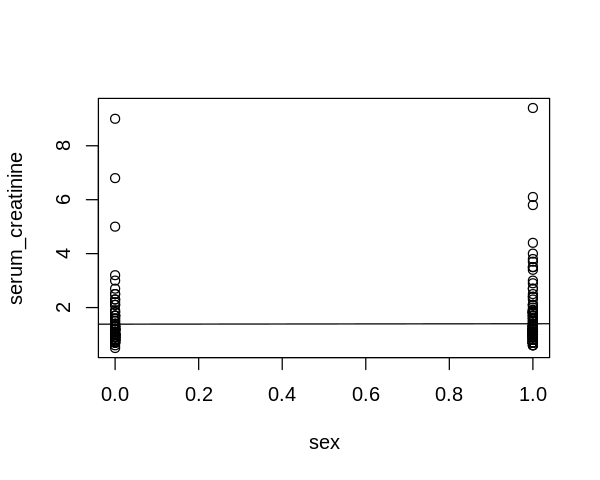

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(sex, serum_creatinine)
abline(lm_sex2)

$$
\widehat{Creatinine}_i = 1.384  + 0.01508 (\text{sex})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately 0.01508 percentage points with intercept (1.384).

In [ ]:
coefficients(lm_sex2)

(Intercept)         sex 
 1.38409524  0.01508002

Anaemia: lm_anaemia2

In [ ]:
lm_anaemia2 <- lm(serum_creatinine ~ anaemia, data = HeartFailure)

The scatterplot of anaemia versus serum creatinine shows very little to no trend due to anaemia, as indicated by the fitted regression line.

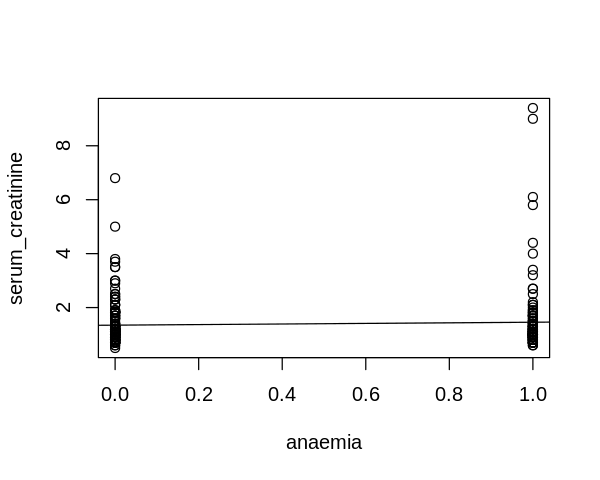

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(anaemia, serum_creatinine)
abline(lm_anaemia2)

$$
\widehat{Creatinine}_i = 1.384  + 0.01508 (\text{anaemia})
$$

The estimated regression equation indicates that serum creatinine increases by approximately 0.1088 percentage points with intercept (1.3469).

In [ ]:
coefficients(lm_anaemia2)

(Intercept)     anaemia 
  1.3469412   0.1087953

Diabetes: lm_diabetes2

In [ ]:
lm_diabetes2 <- lm(serum_creatinine ~ diabetes, data = HeartFailure)

The scatterplot of diabetes versus serum creatinine shows very little to no trend due to diabetes, as indicated by the fitted regression line.

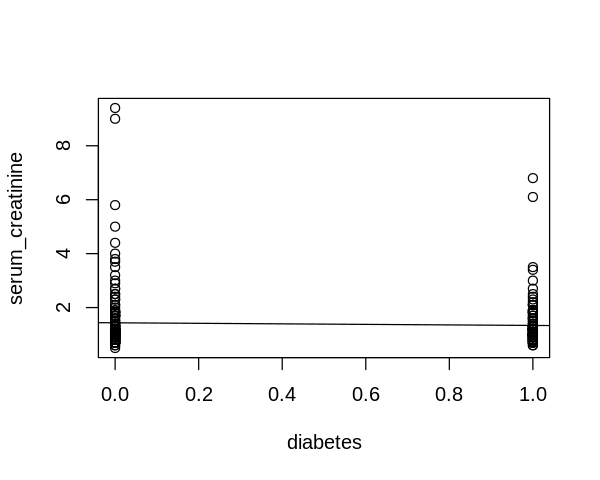

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(diabetes, serum_creatinine)
abline(lm_diabetes2)

$$
\widehat{Creatinine}_i = 1.435  - 0.09836 (\text{diabetes})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately 0.09836 percentage points with intercept (1.435).

In [ ]:
coefficients(lm_diabetes2)

(Intercept)    diabetes 
    1.43500    -0.09836

Smoking: lm_smoking2

In [ ]:
lm_smoking2<- lm(serum_creatinine ~ smoking, data = HeartFailure)

The scatterplot of smoking versus serum creatinine shows very little to no trend due to smoking, as indicated by the fitted regression line. However, the data points are concentrated in the bottom half of the page.

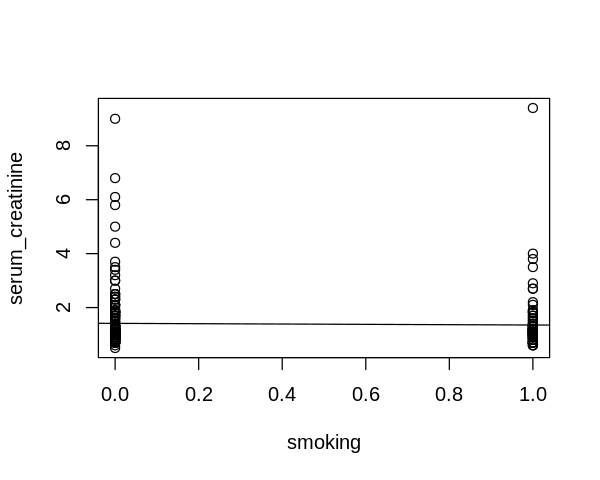

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(smoking, serum_creatinine)
abline(lm_smoking2)

$$
\widehat{Creatinine}_i = 1.41335  - 0.06064 (\text{smoking})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately 0.06064 percentage points with intercept (1.41335).

In [ ]:
coefficients(lm_smoking2)

(Intercept)     smoking 
 1.41334975 -0.06064142

High Blood Pressure: lm_pressure2

In [ ]:
lm_pressure2<- lm(serum_creatinine ~ high_blood_pressure, data = HeartFailure)

The scatterplot of high blood pressure versus serum creatinine shows very little to no trend due to high blood pressure, as indicated by the fitted regression line. However, the data points are concentrated in the bottom half of the page.

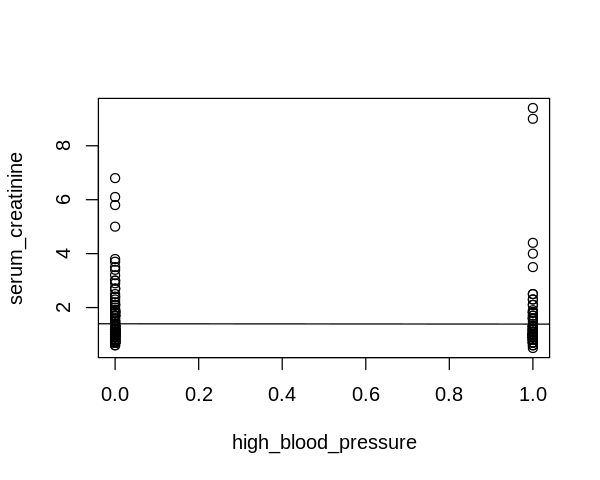

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(high_blood_pressure, serum_creatinine)
abline(lm_pressure2)

$$
\widehat{Creatinine} = 1.39763  - 0.01068 (\text{high_blood_pressure})
$$

The estimated regression equation indicates that serum creatinine decreases by approximately 0.01068 percentage points with intercept (1.39763).

In [ ]:
coefficients(lm_pressure2)

(Intercept) high_blood_pressure 
         1.39762887         -0.01067649

### 2.3 Multiple Linear Regression Model

##### 2.3.1 Model III: Serum Creatinine as a Response

This linear regression model includes all variables except for Death Event and Time for follow up.

In [ ]:
lm_all2<- lm(serum_creatinine ~ .-time -DEATH_EVENT, data = HeartFailure)

A summary of this model is analyzed to examine the variables with the highest p values in order to better the model.

In [ ]:
summary(lm_all2)


Call:
lm(formula = serum_creatinine ~ . - time - DEATH_EVENT, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.1357 -0.4510 -0.2296  0.0638  7.6028 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               6.772e+00  1.899e+00   3.566 0.000424 ***
age                       1.241e-02  5.070e-03   2.448 0.014949 *  
anaemia                   9.565e-02  1.226e-01   0.780 0.435860    
creatinine_phosphokinase  1.581e-05  6.258e-05   0.253 0.800772    
diabetes                 -1.095e-01  1.229e-01  -0.891 0.373591    
ejection_fraction         1.035e-03  5.142e-03   0.201 0.840646    
high_blood_pressure      -3.003e-02  1.251e-01  -0.240 0.810424    
platelets                -1.557e-07  6.163e-07  -0.253 0.800715    
serum_sodium             -4.467e-02  1.374e-02  -3.251 0.001285 ** 
sex                      -4.983e-04  1.426e-01  -0.003 0.997214    
smoking                  -6.953e-02  1.427e-01  -0.487 0.62

It was determined that creatinine phosphokinase, high blood pressure, smoking, sex, ejection fraction, and platelets were hindering the model. Therefore, an updated model without these factors was analyzed.

In [ ]:
lm_update2 <- update(lm_all2, ~ . - creatinine_phosphokinase - high_blood_pressure - smoking - sex  -ejection_fraction - platelets,data = HeartFailure)

In [ ]:
coefficients(lm_update2)

(Intercept)          age      anaemia     diabetes serum_sodium 
  6.69884507   0.01229890   0.09804480  -0.10262719  -0.04430033

Variance Inflation Factors (VIFs) were computed for the new model. All VIF values were approximately 1 (age = 1.02, anaemia = 1.01, diabetes = 1.02, serum sodium = 1.01), indicating no evidence of *multicollinearity* in the model.

In [ ]:
library(car)
vif(lm_update2)

Loading required package: carData



age      anaemia     diabetes serum_sodium 
    1.021645     1.009957     1.019467     1.013345

Additionally, a linear regression model using only age and serum sodium as predictors was analyzed.

In [ ]:
lm_sodiumage <- lm(serum_creatinine ~ age + serum_sodium, data = HeartFailure)

In [ ]:
coefficients(lm_sodiumage)

(Intercept)          age serum_sodium 
  6.43098941   0.01311652  -0.04270829

The interaction term between serum sodium and age allows the effect of serum sodium on serum creatinine to vary across different ages.

$$
Creatinine_i = \beta_0
+ \beta_1(\text{serum sodium}_i)
+ \beta_2(\text{age}_i)
+ \beta_3(\text{serum sodium}_i \times \text{age}_i)
+ \varepsilon_i
\tag{X}
$$

In [ ]:
lm_interactsodiumage <- lm(serum_creatinine ~ serum_sodium * age, data = HeartFailure)

Non-linear Transformations of the Predictors

The quadratic model including both age and age² was estimated to assess potential *curvature* in the relationship between age and serum creatinine.

In [ ]:
lm_ageage <- lm(serum_creatinine ~ age + I(age^2), data = HeartFailure)

A polynomial model of serum sodium was fitted to evaluate potential *nonlinear patterns* in its association with serum creatinine.

In [ ]:
lm_polysodium <- lm(serum_creatinine ~ poly(serum_sodium,4))

A logarithmic transformation of serum sodium was also examined to assess whether the relationship follows a nonlinear rate of change.

In [ ]:
lm_logsodium <- lm(serum_creatinine ~ log(serum_sodium))

# 3. Results

### 3.1 Simple Regression Findings

###### 3.1.1 Model I: Ejection Fraction Results

Age as a Predictor

Age was not a statistically significant predictor of ejection fraction (p = 0.30). The estimated slope coefficient was small (β₁ = 0.0598), suggesting no meaningful linear association between age and cardiac function in this sample.

In [ ]:
summary(lm_age1)


Call:
lm(formula = ejection_fraction ~ age, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.931  -7.944  -1.230   6.368  42.863 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 34.44603    3.57196   9.643   <2e-16 ***
age          0.05980    0.05763   1.038      0.3    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.83 on 297 degrees of freedom
Multiple R-squared:  0.003612,	Adjusted R-squared:  0.000257 
F-statistic: 1.077 on 1 and 297 DF,  p-value: 0.3003


Serum Sodium as a Predictor

Serum sodium was a statistically significant positive predictor of ejection fraction (p = 0.0023). Higher sodium levels were associated with higher ejection fraction values, indicating a small but significant linear relationship.

In [ ]:
summary(lm_sodium1)


Call:
lm(formula = ejection_fraction ~ serum_sodium, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.260  -8.024  -1.204   6.740  41.740 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  -26.3753    20.9428  -1.259  0.20887   
serum_sodium   0.4718     0.1532   3.079  0.00227 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.67 on 297 degrees of freedom
Multiple R-squared:  0.03094,	Adjusted R-squared:  0.02768 
F-statistic: 9.483 on 1 and 297 DF,  p-value: 0.002268


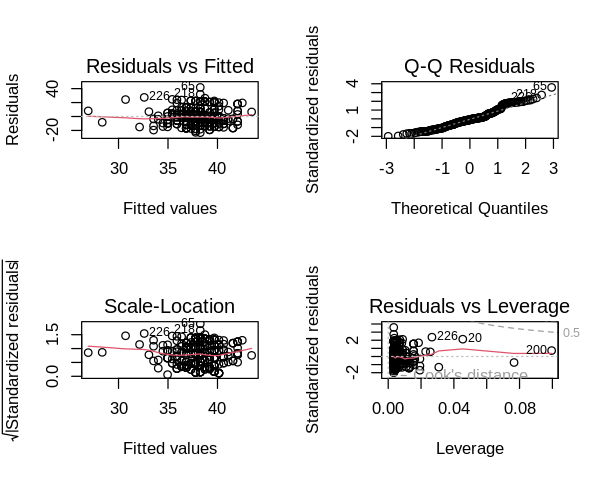

In [ ]:
par(mfrow = c(2, 2))
plot(lm_sodium1)

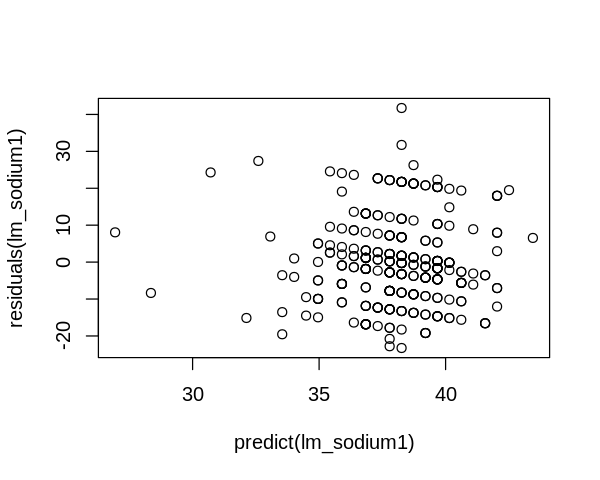

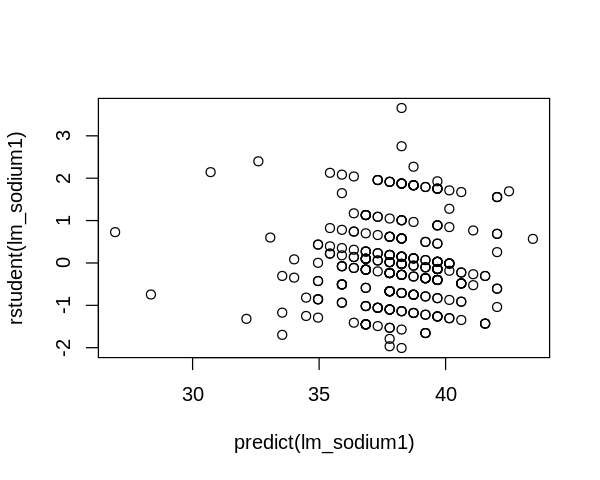

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(predict(lm_sodium1), residuals(lm_sodium1))
plot(predict(lm_sodium1), rstudent(lm_sodium1))

Observation 200 has the highest leverage in this instance.

200 
200

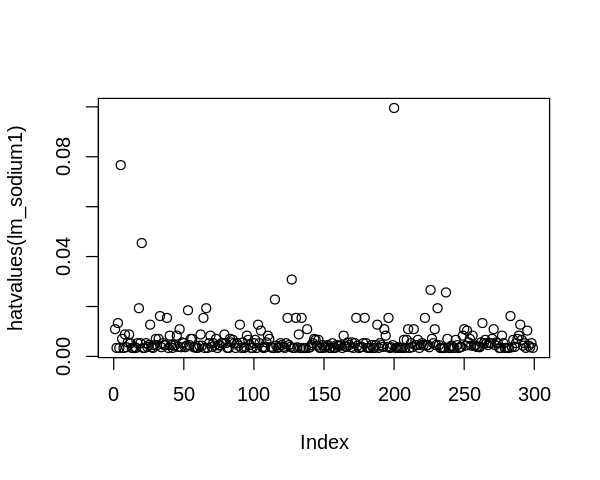

In [ ]:
plot(hatvalues(lm_sodium1))
which.max(hatvalues(lm_sodium1))

Confidence Interval for the Coefficient Estimates

In [ ]:
confint(lm_sodium1)

,2.5 %,97.5 %
(Intercept),-67.5902876,14.8397049
serum_sodium,0.1702854,0.7733004


Confidence Interval and Prediction Inverval for the Prediction of Ejection Fraction for a given value of Serum Sodium

In [ ]:

predict(lm_sodium1, data.frame(serum_sodium = (c(5, 10, 15))),
    interval = "confidence")
predict(lm_sodium1, data.frame(serum_sodium = (c(5, 10, 15))),
    interval = "prediction")

,fit,lwr,upr
1,-24.01633,-63.72460,15.69194
2,-21.65736,-59.85897,16.54425
3,-19.29840,-55.99342,17.39662


,fit,lwr,upr
1,-24.01633,-69.88780,21.85515
2,-21.65736,-66.23099,22.91627
3,-19.29840,-62.58777,23.99098


Serum Creatinine as a Predictor

Serum creatinine was not statistically significant in predicting ejection fraction (p > 0.05), suggesting no evidence of a linear relationship between renal dysfunction and cardiac output.

In [ ]:
summary(lm_creatinine1)


Call:
lm(formula = ejection_fraction ~ serum_creatinine, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-24.160  -8.122  -0.147   6.859  41.889 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       38.2638     1.1515  33.229   <2e-16 ***
serum_creatinine  -0.1293     0.6638  -0.195    0.846    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.85 on 297 degrees of freedom
Multiple R-squared:  0.0001277,	Adjusted R-squared:  -0.003239 
F-statistic: 0.03795 on 1 and 297 DF,  p-value: 0.8457


Creatinine Phosphokinase as a Predictor

Creatinine phosphokinase levels were not significantly associated with ejection fraction (p = 0.448), indicating no detectable linear relationship.

In [ ]:
summary(lm_phosphokinase1)


Call:
lm(formula = ejection_fraction ~ creatinine_phosphokinase, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-24.084  -8.267  -0.325   6.683  41.916 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)              38.3964376  0.7989704   48.06   <2e-16 ***
creatinine_phosphokinase -0.0005376  0.0007071   -0.76    0.448    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.84 on 297 degrees of freedom
Multiple R-squared:  0.001943,	Adjusted R-squared:  -0.001417 
F-statistic: 0.5782 on 1 and 297 DF,  p-value: 0.4476


Platelet Count as a Predictor

Platelet count did not significantly predict ejection fraction (p = 0.213), suggesting no meaningful linear association between platelet levels and cardiac function.

In [ ]:
summary(lm_platelet1)


Call:
lm(formula = ejection_fraction ~ platelets, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.233  -8.095  -0.657   6.470  41.916 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 3.578e+01  1.967e+00  18.192   <2e-16 ***
platelets   8.734e-06  7.003e-06   1.247    0.213    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.82 on 297 degrees of freedom
Multiple R-squared:  0.00521,	Adjusted R-squared:  0.00186 
F-statistic: 1.555 on 1 and 297 DF,  p-value: 0.2133


Sex as a Predictor

Sex was found to be a statistically significant predictor of ejection fraction (β = −3.673, p = 0.0102). The negative coefficient indicates that males (coded as 1) have, on average, a 3.67 percentage point lower ejection fraction compared to females (coded as 0).

In [ ]:
summary(lm_sex1)


Call:
lm(formula = ejection_fraction ~ sex, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-25.467  -6.794  -1.794   8.206  39.533 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   40.467      1.144  35.370   <2e-16 ***
sex           -3.673      1.420  -2.586   0.0102 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.72 on 297 degrees of freedom
Multiple R-squared:  0.02202,	Adjusted R-squared:  0.01873 
F-statistic: 6.687 on 1 and 297 DF,  p-value: 0.01019


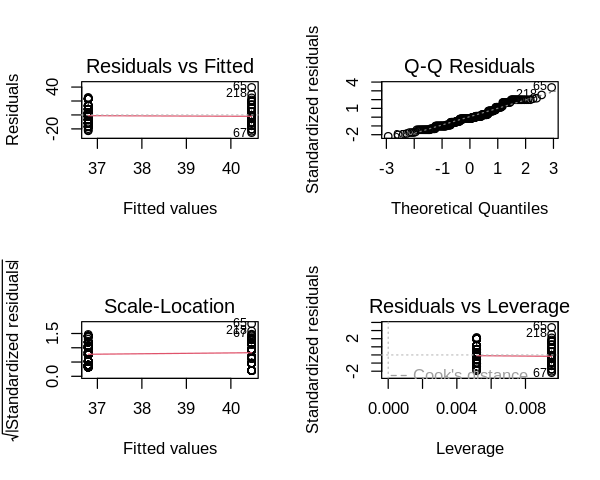

In [ ]:
par(mfrow = c(2, 2))
plot(lm_sex1)

Observation 5 has the highest leverage in this instance.

5 
5

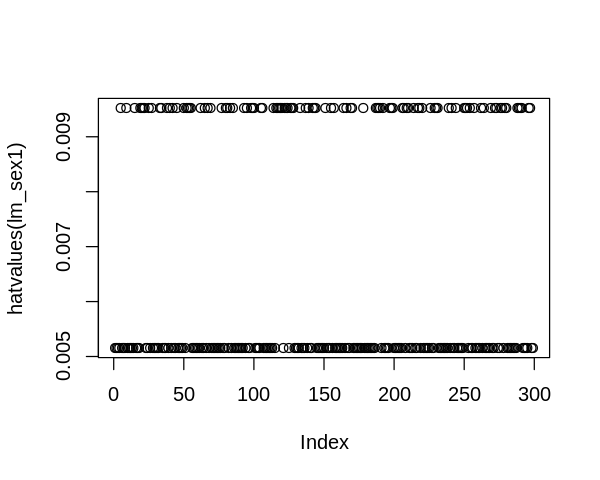

In [ ]:
plot(hatvalues(lm_sex1))
which.max(hatvalues(lm_sex1))

Confidence Interval for the Coefficient Estimates

In [ ]:
confint(lm_sex1)

,2.5 %,97.5 %
(Intercept),38.215102,42.7182316
sex,-6.468093,-0.8776116


Confidence Interval and Prediction Interval for the Prediction of Ejection Fraction

In [ ]:

predict(lm_sex1, data.frame(sex = (c(5, 10, 15))),
    interval = "confidence")
predict(lm_sex1, data.frame(sex = (c(5, 10, 15))),
    interval = "prediction")

,fit,lwr,upr
1,22.102405,9.866869,34.33794
2,3.738144,-22.434660,29.91095
3,-14.626117,-54.763276,25.51104


,fit,lwr,upr
1,22.102405,-4.012926,48.21774
2,3.738144,-31.151939,38.62823
3,-14.626117,-60.921837,31.66960


Anaemia as a Predictor

Anaemia status was not statistically significant (p > 0.05), indicating no linear association with ejection fraction in this analysis.

In [ ]:
summary(lm_anaemia1)


Call:
lm(formula = ejection_fraction ~ anaemia, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.759  -7.759  -0.512   6.488  42.241 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  37.7588     0.9088  41.550   <2e-16 ***
anaemia       0.7528     1.3835   0.544    0.587    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.85 on 297 degrees of freedom
Multiple R-squared:  0.0009958,	Adjusted R-squared:  -0.002368 
F-statistic: 0.2961 on 1 and 297 DF,  p-value: 0.5868


Diabetes as a Predictor

Diabetes was not a statistically significant predictor of ejection fraction (p > 0.05), suggesting no direct linear association.

In [ ]:
summary(lm_diabetes1)


Call:
lm(formula = ejection_fraction ~ diabetes, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-24.132  -8.132  -0.132   6.868  41.868 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  38.1322     0.8987  42.431   <2e-16 ***
diabetes     -0.1162     1.3899  -0.084    0.933    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.85 on 297 degrees of freedom
Multiple R-squared:  2.353e-05,	Adjusted R-squared:  -0.003343 
F-statistic: 0.006987 on 1 and 297 DF,  p-value: 0.9334


Smoking as a Predictor

Smoking status was not significantly associated with ejection fraction (p > 0.05).

In [ ]:
summary(lm_smoking1)


Call:
lm(formula = ejection_fraction ~ smoking, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-24.631  -8.631  -0.631   6.369  41.369 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  38.6305     0.8302  46.534   <2e-16 ***
smoking      -1.7035     1.4651  -1.163    0.246    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.83 on 297 degrees of freedom
Multiple R-squared:  0.004531,	Adjusted R-squared:  0.00118 
F-statistic: 1.352 on 1 and 297 DF,  p-value: 0.2459


High Blood Pressure as a Predictor

High blood pressure was not statistically significant in predicting ejection fraction (p > 0.05).

In [ ]:
summary(lm_pressure1)


Call:
lm(formula = ejection_fraction ~ high_blood_pressure, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.871  -7.871  -0.476   6.524  42.129 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)          37.8711     0.8509  44.509   <2e-16 ***
high_blood_pressure   0.6051     1.4358   0.421    0.674    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.85 on 297 degrees of freedom
Multiple R-squared:  0.0005975,	Adjusted R-squared:  -0.002767 
F-statistic: 0.1776 on 1 and 297 DF,  p-value: 0.6738


######3.1.2 Model II: Serum Creatinine Results

Age as a Predictor

Age was a statistically significant positive predictor of serum creatinine (β₁ = 0.0138, p = 0.0058). On average, each additional year of age was associated with an increase of approximately 0.014 mg/dL in serum creatinine.

In [ ]:
summary(lm_age2)


Call:
lm(formula = serum_creatinine ~ age, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9900 -0.4516 -0.2716  0.0981  7.7408 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept) 0.551649   0.308810   1.786   0.0751 . 
age         0.013845   0.004982   2.779   0.0058 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.023 on 297 degrees of freedom
Multiple R-squared:  0.02534,	Adjusted R-squared:  0.02206 
F-statistic: 7.722 on 1 and 297 DF,  p-value: 0.005803


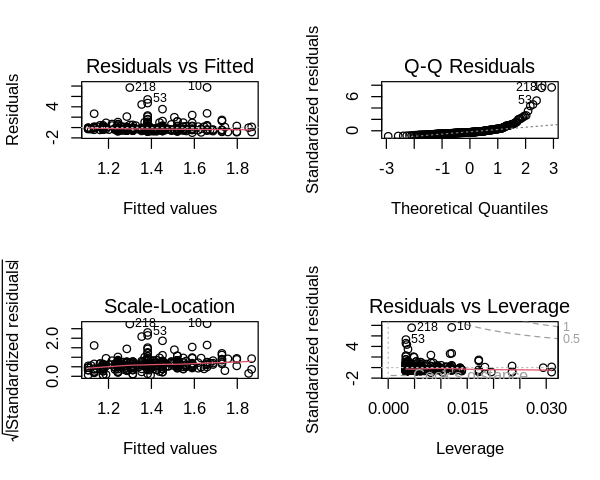

In [ ]:
par(mfrow = c(2, 2))
plot(lm_age2)

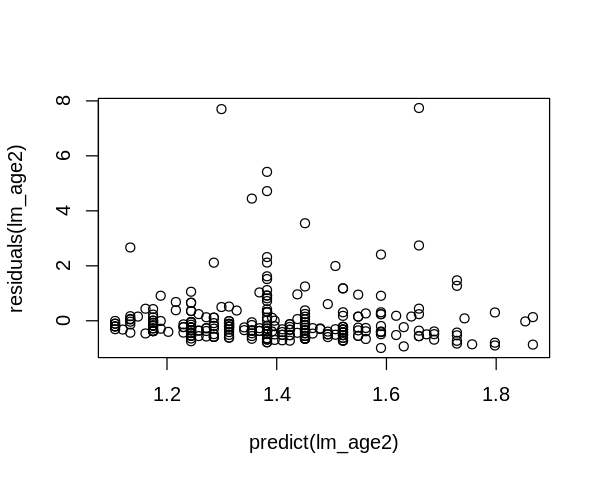

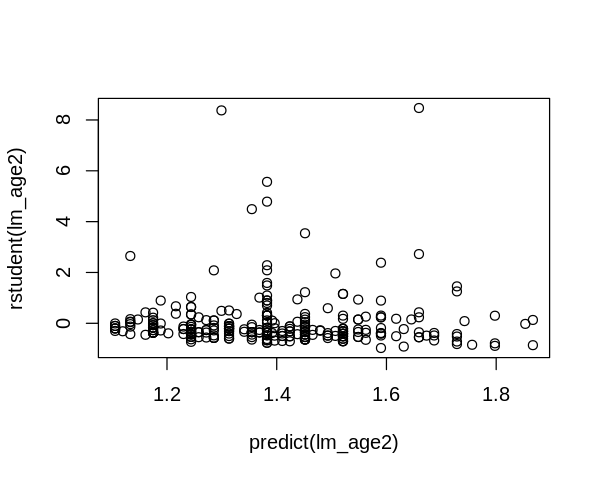

In [ ]:
plot(predict(lm_age2), residuals(lm_age2))
plot(predict(lm_age2), rstudent(lm_age2))

In this case, observation 27 has the highest leverage.

27 
27

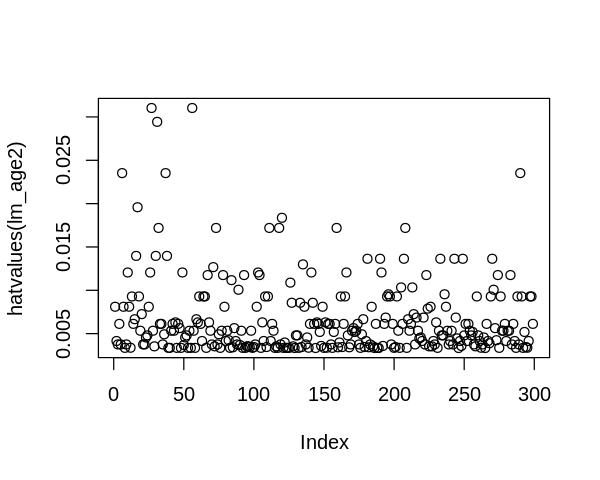

In [ ]:
plot(hatvalues(lm_age2))
which.max(hatvalues(lm_age2))

Confidence Interval for the Coefficient Estimates

In [ ]:
confint(lm_age2)

,2.5 %,97.5 %
(Intercept),-0.056083779,1.15938255
age,0.004039768,0.02364974


Confidence Interval and Prediction Inverval for the Prediction of Ejection Fraction for a given value of Serum Creatinine

In [ ]:

predict(lm_age2, data.frame(age = (c(5, 10, 15))),
    interval = "confidence")
predict(lm_age2, data.frame(age = (c(5, 10, 15))),
    interval = "prediction")

,fit,lwr,upr
1,0.6208732,0.06117795,1.180568
2,0.6900969,0.17825248,1.201941
3,0.7593207,0.29508192,1.223559


,fit,lwr,upr
1,0.6208732,-1.468795,2.710541
2,0.6900969,-1.387266,2.767460
3,0.7593207,-1.306828,2.825469


Serum Sodium as a Predictor

Serum sodium was a statistically significant negative predictor of serum creatinine (β₁ = −0.0443, p = 0.0010). Higher sodium levels were associated with lower serum creatinine concentrations.

In [ ]:
summary(lm_sodium2)


Call:
lm(formula = serum_creatinine ~ serum_sodium, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.0433 -0.4329 -0.2443  0.0557  7.8454 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   7.45097    1.82610   4.080 5.79e-05 ***
serum_sodium -0.04433    0.01336  -3.319  0.00102 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.018 on 297 degrees of freedom
Multiple R-squared:  0.03576,	Adjusted R-squared:  0.03251 
F-statistic: 11.01 on 1 and 297 DF,  p-value: 0.001017


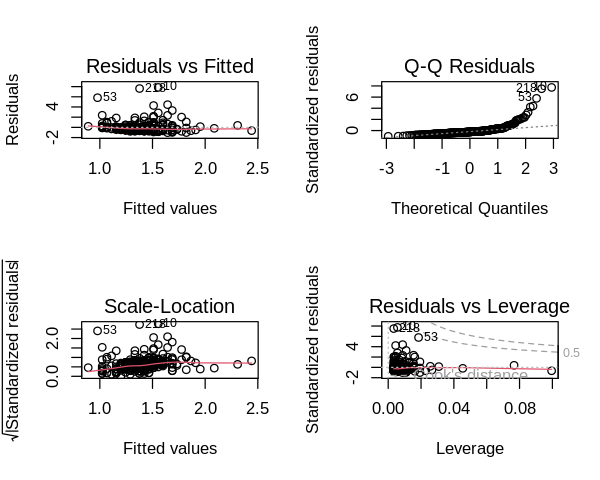

In [ ]:
par(mfrow = c(2, 2))
plot(lm_sodium2)

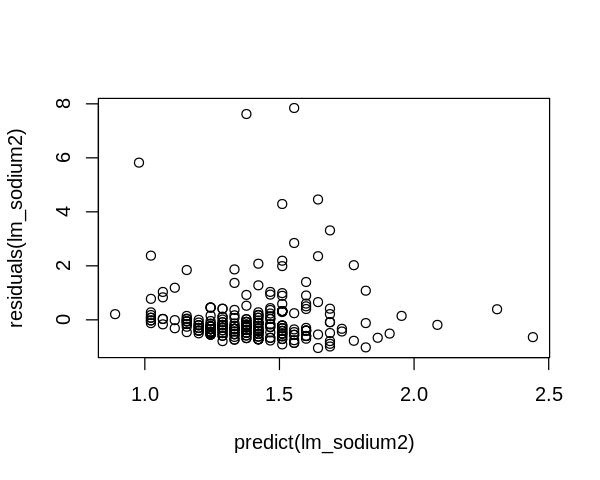

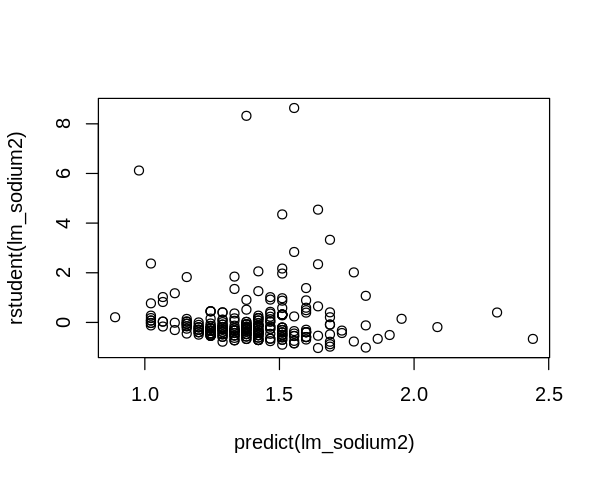

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 4)
plot(predict(lm_sodium2), residuals(lm_sodium2))
plot(predict(lm_sodium2), rstudent(lm_sodium2))

The observation with the largest leverage statistic is 200.

200 
200

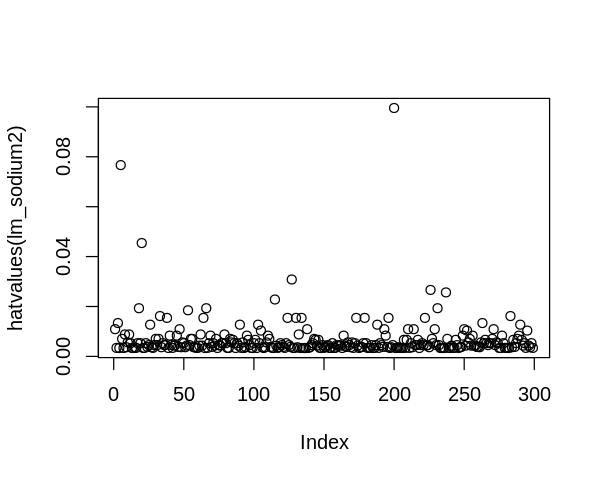

In [ ]:
plot(hatvalues(lm_sodium2))
which.max(hatvalues(lm_sodium2))

Confidence Interval for the Coefficient Estimates

In [ ]:
confint(lm_sodium2)

,2.5 %,97.5 %
(Intercept),3.85723970,11.04470626
serum_sodium,-0.07062346,-0.01804369


Confidence Interval and Prediction Inverval for the Prediction of Serum Creatinine for a given value of Serum Sodium

In [ ]:

predict(lm_sodium2, data.frame(serum_sodium = (c(5, 10, 15))),
    interval = "confidence")
predict(lm_sodium2, data.frame(serum_sodium = (c(5, 10, 15))),
    interval = "prediction")

,fit,lwr,upr
1,7.229305,3.766950,10.691660
2,7.007637,3.676655,10.338619
3,6.785969,3.586354,9.985584


,fit,lwr,upr
1,7.229305,3.229551,11.22906
2,7.007637,3.121049,10.89423
3,6.785969,3.011361,10.56058


Ejection Fraction as a Predictor

Ejection fraction did not show a statistically significant linear association with serum creatinine levels (p > 0.05).

In [ ]:
summary(lm_ejection2)


Call:
lm(formula = serum_creatinine ~ ejection_fraction, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9019 -0.4870 -0.2940  0.0060  8.0031 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1.431505   0.202236   7.078 1.06e-11 ***
ejection_fraction -0.000988   0.005072  -0.195    0.846    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.036 on 297 degrees of freedom
Multiple R-squared:  0.0001277,	Adjusted R-squared:  -0.003239 
F-statistic: 0.03795 on 1 and 297 DF,  p-value: 0.8457


Creatinine Phosphokinase as a Predictor

Creatinine phosphokinase levels were not significantly associated with serum creatinine (p > 0.05).

In [ ]:
summary(lm_phosphokinase2)


Call:
lm(formula = serum_creatinine ~ creatinine_phosphokinase, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8599 -0.4832 -0.2938  0.0046  7.9981 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               1.404e+00  6.990e-02  20.087   <2e-16 ***
creatinine_phosphokinase -1.749e-05  6.186e-05  -0.283    0.778    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.036 on 297 degrees of freedom
Multiple R-squared:  0.0002692,	Adjusted R-squared:  -0.003097 
F-statistic: 0.07999 on 1 and 297 DF,  p-value: 0.7775


Platelet Count as a Predictor

Platelet count was not a statistically significant predictor of serum creatinine.

In [ ]:
summary(lm_platelet2)


Call:
lm(formula = serum_creatinine ~ platelets, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8420 -0.4641 -0.2890  0.0543  8.0604 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.509e+00  1.722e-01   8.759   <2e-16 ***
platelets   -4.358e-07  6.132e-07  -0.711    0.478    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.035 on 297 degrees of freedom
Multiple R-squared:  0.001697,	Adjusted R-squared:  -0.001664 
F-statistic: 0.5049 on 1 and 297 DF,  p-value: 0.4779


Sex as a Predictor

Sex was not statistically significant in predicting serum creatinine levels.

In [ ]:
summary(lm_sex2)


Call:
lm(formula = serum_creatinine ~ sex, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8841 -0.4841 -0.2992  0.0084  8.0008 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.38410    0.10113   13.69   <2e-16 ***
sex          0.01508    0.12554    0.12    0.904    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.036 on 297 degrees of freedom
Multiple R-squared:  4.858e-05,	Adjusted R-squared:  -0.003318 
F-statistic: 0.01443 on 1 and 297 DF,  p-value: 0.9045


Anaemia as a Predictor

Anaemia was not significantly associated with serum creatinine.

In [ ]:
summary(lm_anaemia2)


Call:
lm(formula = serum_creatinine ~ anaemia, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8557 -0.4557 -0.2557  0.0443  7.9443 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.34694    0.07937   16.97   <2e-16 ***
anaemia      0.10880    0.12083    0.90    0.369    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.035 on 297 degrees of freedom
Multiple R-squared:  0.002722,	Adjusted R-squared:  -0.0006358 
F-statistic: 0.8107 on 1 and 297 DF,  p-value: 0.3687


Diabetes as a Predictor

Diabetes status did not significantly predict serum creatinine levels.

In [ ]:
summary(lm_diabetes2)


Call:
lm(formula = serum_creatinine ~ diabetes, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9350 -0.4366 -0.3350  0.0142  7.9650 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.43500    0.07847   18.29   <2e-16 ***
diabetes    -0.09836    0.12136   -0.81    0.418    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.035 on 297 degrees of freedom
Multiple R-squared:  0.002207,	Adjusted R-squared:  -0.001153 
F-statistic: 0.6568 on 1 and 297 DF,  p-value: 0.4183


Smoking as a Predictor

Smoking status was not statistically significant.

In [ ]:
summary(lm_smoking2)


Call:
lm(formula = serum_creatinine ~ smoking, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9133 -0.4527 -0.2527  0.0170  8.0473 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.41335    0.07270  19.440   <2e-16 ***
smoking     -0.06064    0.12831  -0.473    0.637    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.036 on 297 degrees of freedom
Multiple R-squared:  0.0007515,	Adjusted R-squared:  -0.002613 
F-statistic: 0.2234 on 1 and 297 DF,  p-value: 0.6368


High Blood Pressure as a Predictor

High blood pressure did not show a statistically significant linear association with serum creatinine.

In [ ]:
summary(lm_pressure2)


Call:
lm(formula = serum_creatinine ~ high_blood_pressure, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8870 -0.4870 -0.2976  0.0024  8.0130 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)          1.39763    0.07440  18.786   <2e-16 ***
high_blood_pressure -0.01068    0.12554  -0.085    0.932    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.036 on 297 degrees of freedom
Multiple R-squared:  2.435e-05,	Adjusted R-squared:  -0.003343 
F-statistic: 0.007232 on 1 and 297 DF,  p-value: 0.9323


### 3.2 Multiple Regression Findings

#####3.2.1 Model III: Serum Creatinine Results

The multiple regression results are consistent with the findings from the simple linear regression analyses. In both approaches, age and serum sodium remained statistically significant predictors of serum creatinine. The p-values for age (p = 0.0138) and serum sodium (p < 0.001) are both below the 0.05 threshold. The overall test for the regression model was statistically significant (p = 0.00072).

In [ ]:
summary(lm_update2)


Call:
lm(formula = serum_creatinine ~ age + anaemia + diabetes + serum_sodium, 
    data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.2133 -0.4491 -0.2328  0.0496  7.6081 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.698845   1.867535   3.587 0.000392 ***
age           0.012299   0.004963   2.478 0.013765 *  
anaemia       0.098045   0.118306   0.829 0.407925    
diabetes     -0.102627   0.119353  -0.860 0.390564    
serum_sodium -0.044300   0.013324  -3.325 0.000997 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.008 on 294 degrees of freedom
Multiple R-squared:  0.063,	Adjusted R-squared:  0.05025 
F-statistic: 4.942 on 4 and 294 DF,  p-value: 0.0007196


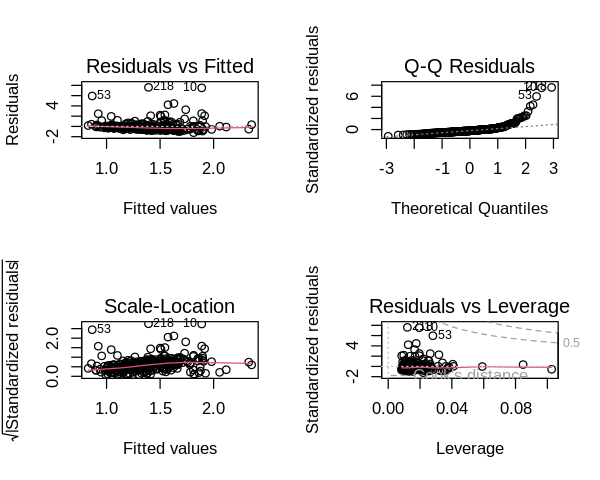

In [ ]:
par(mfrow = c(2, 2))
plot(lm_update2)

Confidence Interval for the Coefficient Estimates

In [ ]:
confint(lm_update2)

,2.5 %,97.5 %
(Intercept),3.023413144,10.37427699
age,0.002531843,0.02206595
anaemia,-0.134789571,0.33087918
diabetes,-0.337521118,0.13226675
serum_sodium,-0.070522420,-0.01807824


The reduced model (age + serum sodium) is more statistically *efficient* than the larger model that included anaemia and diabetes.

In [ ]:
summary(lm_sodiumage)


Call:
lm(formula = serum_creatinine ~ age + serum_sodium, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.2199 -0.4540 -0.2014  0.0710  7.7118 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.43099    1.84742   3.481 0.000575 ***
age           0.01312    0.00491   2.671 0.007976 ** 
serum_sodium -0.04271    0.01324  -3.226 0.001394 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.007 on 296 degrees of freedom
Multiple R-squared:  0.05845,	Adjusted R-squared:  0.05209 
F-statistic: 9.188 on 2 and 296 DF,  p-value: 0.0001345


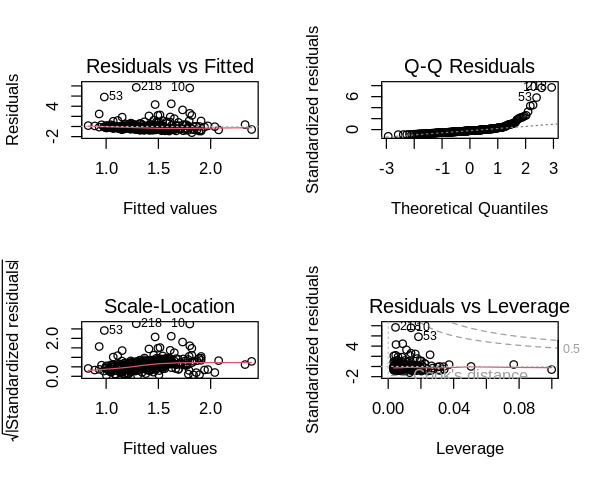

In [ ]:
par(mfrow = c(2, 2))
plot(lm_sodiumage)

The interaction model including serum sodium, age, and their interaction term did not provide a significant interaction effect (p = 0.389). Although the overall model was statistically significant (p = 0.00034), the interaction term does not improve the model.

In [ ]:
summary(lm_interactsodiumage)


Call:
lm(formula = serum_creatinine ~ serum_sodium * age, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.2930 -0.4415 -0.2090  0.0493  7.7093 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)
(Intercept)      -2.004777   9.954009  -0.201    0.841
serum_sodium      0.019161   0.072947   0.263    0.793
age               0.151420   0.160433   0.944    0.346
serum_sodium:age -0.001015   0.001176  -0.862    0.389

Residual standard error: 1.008 on 295 degrees of freedom
Multiple R-squared:  0.06082,	Adjusted R-squared:  0.05127 
F-statistic: 6.368 on 3 and 295 DF,  p-value: 0.0003399


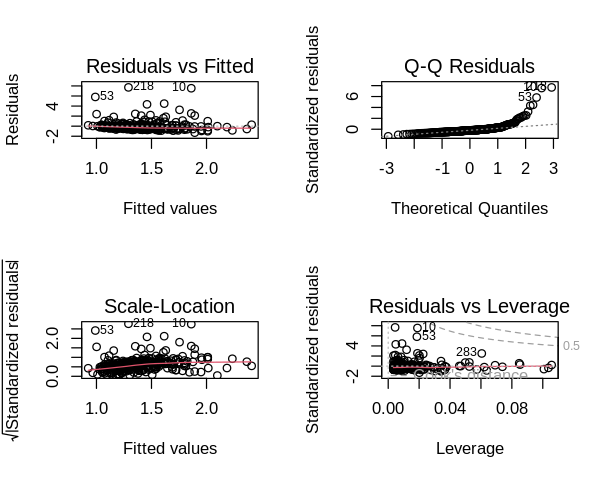

In [ ]:
par(mfrow = c(2, 2))
plot(lm_interactsodiumage)

Non Linear Predictors

The quadratic term for age was not statistically significant, and ANOVA comparison indicates that adding age² does not significantly improve model fit (p = 0.603).

In [ ]:
summary(lm_ageage)


Call:
lm(formula = serum_creatinine ~ age + I(age^2), data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9919 -0.4576 -0.2716  0.1076  7.7632 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.1119063  1.3117920  -0.085    0.932
age          0.0355978  0.0420890   0.846    0.398
I(age^2)    -0.0001717  0.0003299  -0.521    0.603

Residual standard error: 1.024 on 296 degrees of freedom
Multiple R-squared:  0.02623,	Adjusted R-squared:  0.01965 
F-statistic: 3.987 on 2 and 296 DF,  p-value: 0.01956


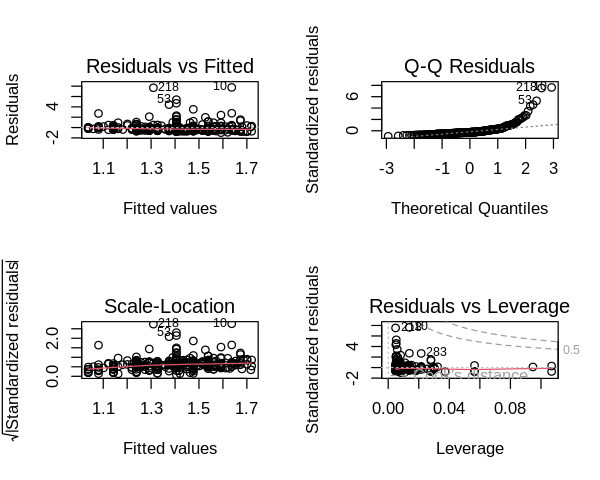

In [ ]:
par(mfrow = c(2, 2))
plot(lm_ageage)

ANOVA

In [ ]:
anova(lm_age2,lm_ageage)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,297,310.8412,NA,NA,NA,NA
2,296,310.5570,1,0.284248,0.2709243,0.6031015


The fourth-degree polynomial model for serum sodium produced a statistically significant improvement in model fit (Adjusted R² = 0.074), exceeding that of the linear model.

In [ ]:
summary(lm_polysodium)


Call:
lm(formula = serum_creatinine ~ poly(serum_sodium, 4))

Residuals:
    Min      1Q  Median      3Q     Max 
-1.9845 -0.3980 -0.1612  0.0968  7.7347 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)             1.39388    0.05757  24.210  < 2e-16 ***
poly(serum_sodium, 4)1 -3.37694    0.99555  -3.392 0.000789 ***
poly(serum_sodium, 4)2  1.00831    0.99555   1.013 0.311980    
poly(serum_sodium, 4)3  3.28483    0.99555   3.300 0.001088 ** 
poly(serum_sodium, 4)4  2.07955    0.99555   2.089 0.037582 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9955 on 294 degrees of freedom
Multiple R-squared:  0.08634,	Adjusted R-squared:  0.07391 
F-statistic: 6.945 on 4 and 294 DF,  p-value: 2.355e-05


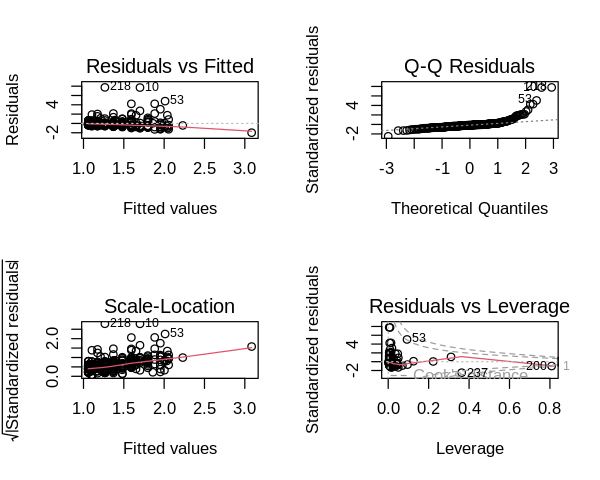

In [ ]:
par(mfrow = c(2, 2))
plot(lm_polysodium)

There is a statistically significant negative association between log-transformed serum sodium and serum creatinine (p = 0.000915), although the model explains only a small proportion (3.6%) of the variability in serum creatinine.

In [ ]:
summary(lm_logsodium)


Call:
lm(formula = serum_creatinine ~ log(serum_sodium))

Residuals:
    Min      1Q  Median      3Q     Max 
-1.0425 -0.4327 -0.2445  0.0530  7.8482 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)         30.843      8.793   3.508 0.000522 ***
log(serum_sodium)   -5.990      1.788  -3.349 0.000915 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.017 on 297 degrees of freedom
Multiple R-squared:  0.03639,	Adjusted R-squared:  0.03315 
F-statistic: 11.22 on 1 and 297 DF,  p-value: 0.000915


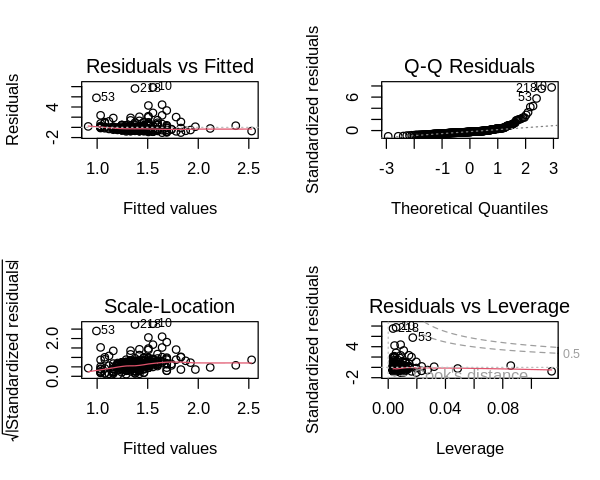

In [ ]:
par(mfrow = c(2, 2))
plot(lm_logsodium)

# 4. Discussion

#### 4.1 Model I: Simple Linear Regression Ejection Fraction

Serum sodium was a statistically significant positive predictor of ejection fraction (p = 0.0023). Higher sodium levels were associated with
higher ejection fraction values, with a small but significant linear relationship. Sex was found to be a statistically significant predictor of ejection fraction (β = −3.673, p = 0.0102). The negative coefficient indicates that
males (coded as 1) have, on average, a 3.67 percentage point lower ejection fraction compared to females (coded as 0).

These findings suggest that both physiological factors (serum sodium) and demographic characteristics (sex) may play a role in explaining variation in cardiac function within this heart failure population, although the overall *effect sizes* indicate that additional factors likely contribute to variability.

#### 4.2 Model II: Simple Linear Regression Serum Creatinine

Age was a statistically significant positive predictor of serum creatinine (β₁ = 0.0138, p = 0.0058). On average, each additional year of age
was associated with an increase of approximately 0.014 mg/dL in serum creatinine. Serum sodium was a statistically significant negative predictor of serum creatinine (β₁ = −0.0443, p = 0.0010). Higher sodium levels were
associated with lower serum creatinine concentrations.

These effects move in opposite directions, suggesting that while renal function tends to decline gradually with age, higher sodium levels are associated with comparatively lower creatinine values within this dataset.

#### 4.2 Model III: Multiple Linear Regression Serum Creatinine

The multiple regression results are consistent with the findings from the simple linear regression analyses. In both approaches, age and
serum sodium remained statistically significant predictors of serum creatinine. The p-values for age (p = 0.0138) and serum sodium (p <
0.001) are both below the 0.05 threshold. The overall test for the regression model was statistically significant (p = 0.00072). However, the reduced model (age + serum sodium) is more statistically efficient than the larger model that included anaemia and diabetes. Additionally, there is a statistically significant negative association between log-transformed serum sodium and serum creatinine (p = 0.000915),
although the model explains only a small proportion (3.6%) of the variability in serum creatinine.

The persistence of significance after adjusting for additional variables indicates that the relationships between age, serum sodium, and creatinine are not driven by any confounding from the other clinical factors considered.

#5. Conclusion

In conclusion, the regression analyses indicate that age, serum sodium, and sex are significantly associated with serum creatinine or ejection fraction. These two variables are recognized in prior research as critical indicators of heart failure patient survival. While the models explain only a small portion of variability, the findings reinforce the potential relevance of clinical and demographic factors in understanding patient risk and survival in heart failure populations. However, the low R² values indicate that heart failure progression is influenced by complex mechanisms beyond the variables
included in this analysis. Future modeling approaches incorporating interaction terms, additional biomarkers, or nonlinear machine
learning methods could further advance this research.

# 6. Appendix

### 6.1 Writing Functions

In [ ]:
install.packages('ISLR')
install.packages('ISLR2')
library(MASS)
library(ISLR2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston




In [ ]:
LoadLibraries <- function() {
 library(ISLR2)
 library(MASS)
 print("The libraries have been loaded.")
}

In [ ]:
LoadLibraries

function () 
{
    library(ISLR2)
    library(MASS)
    print("The libraries have been loaded.")
}

In [ ]:
LoadLibraries()

[1] "The libraries have been loaded."


### 6.2 Treatment of Qualitative Predictors

Several clinical predictors in the dataset (diabetes, sex, high_blood_pressure, and anaemia) are qualitative in nature. These variables were already preprocessed and coded as binary indicators (0 = absence, 1 = presence). Therefore, they were directly incorporated into the regression models as dummy variables without requiring additional factor conversion or contrast specification.

###6.3. Code for Variable Table

In [ ]:
variable_table <- data.frame(
  Variable = c("age",
               "anaemia",
               "creatinine_phosphokinase",
               "diabetes",
               "ejection_fraction",
               "high_blood_pressure",
               "platelets",
               "sex",
               "serum_creatinine",
               "serum_sodium",
               "smoking",
               "time",
               "death_event"),

  Description = c("Age of the patient (years)",
                  "Decrease of red blood cells or hemoglobin (boolean)",
                  "Level of CPK enzyme in blood (mcg/L)",
                  "Presence of diabetes (boolean)",
                  "Percentage of blood leaving heart at each contraction",
                  "Presence of hypertension (boolean)",
                  "Platelets in blood (kiloplatelets/mL)",
                  "Sex (binary: 0 = female, 1 = male)",
                  "Serum creatinine level (mg/dL)",
                  "Serum sodium level (mEq/L)",
                  "Smoking status (boolean)",
                  "Follow-up period (days)",
                  "Death during follow-up (boolean)")
)

### 6.4 Install Car

In [ ]:
install.packages('car')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘Rdpack’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


